# UNIVERSIDAD AUTÓNOMA DE OCCIDENTE
## FACULTAD DE INGENIERÍA
### MAESTRÍA EN INTELIGENCIA ARTIFICIAL Y CIENCIAS DE DATOS

---

**Curso:** Gestión de Proyectos de IA y Ciencia de Datos  
**Proyecto:** Clasificación de Variedades de Frijol Seco (Dry Bean Dataset)  
**Metodología:** TDSP (Team Data Science Process) y Scrum ML  

---

## Introducción
Este notebook documenta la fase de **Modelado y Evaluación** del proyecto. El objetivo es desarrollar un sistema de clasificación capaz de identificar siete tipos de frijoles secos basándose en sus características morfológicas, comparando un modelo base (Logistic Regression) frente a un modelo avanzado (Random Forest).

## 1. Preparación del Entorno y Carga de Datos
En esta sección importamos los datos procesados previamente por el equipo de ingeniería de datos. Siguiendo la estructura del repositorio, consumimos los archivos directamente desde la carpeta `data/processed/`.

In [ ]:
import pandas as pd
repo_url = "https://raw.githubusercontent.com/deybar/laboratorio_drybean_ml/main/data/processed/"

# Cargamos los 4 archivos clave que Luisa procesó
X_train = pd.read_csv(f"{repo_url}X_train.csv")
X_test = pd.read_csv(f"{repo_url}X_test.csv")
y_train = pd.read_csv(f"{repo_url}y_train.csv").values.ravel()
y_test = pd.read_csv(f"{repo_url}y_test.csv").values.ravel()

print("¡Datos cargados directamente desde el repositorio del equipo!")

¡Datos cargados directamente desde el repositorio del equipo!


## 2. Modelo Baseline: Regresión Logística
Establecemos un punto de referencia (baseline) utilizando un modelo lineal. Implementamos un **Pipeline** para asegurar que el escalado de características (`StandardScaler`) se realice de manera correcta sin incurrir en fuga de datos.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Creamos el 'Pipeline', que es como una caja que contiene varios procesos en orden
baseline_model = Pipeline(steps=[

    # PASO 1: Escalado de datos (StandardScaler)
    ("scaler", StandardScaler()),

    # PASO 2: El Modelo (LogisticRegression)
    # 'max_iter=1000': Le damos 1000 intentos al algoritmo para encontrar la solución.
    # 'random_state=42': Fijamos la semilla del azar para que, si corres esto mil veces,
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



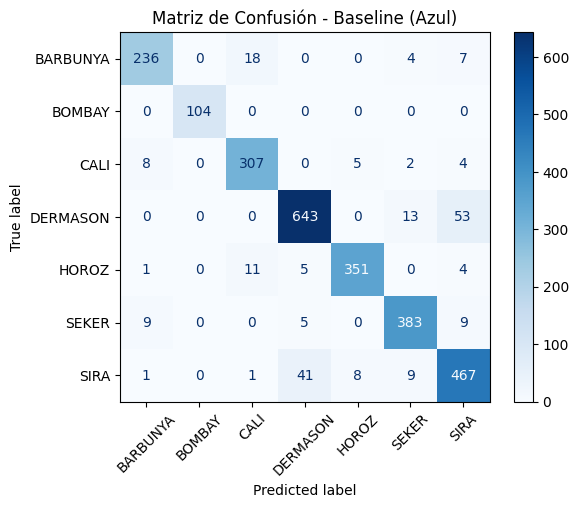

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predecir con los datos
y_pred = baseline_model.predict(X_test)

# Mostrar el reporte escrito
print(classification_report(y_test, y_pred))

# Mostrar la Matriz de Confusión (Gráfica)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusión - Baseline (Azul)")
plt.show()

### Interpretación de la Matriz de Confusión
La matriz de confusión nos permite visualizar el desempeño del algoritmo por cada clase.
* **Aciertos (Diagonal):** Se observa que el modelo identifica casi a la perfección variedades como **BOMBAY**.
* **Análisis de Errores:** El mayor reto se encuentra en la diferenciación entre **SIRA** y **DERMASON**.

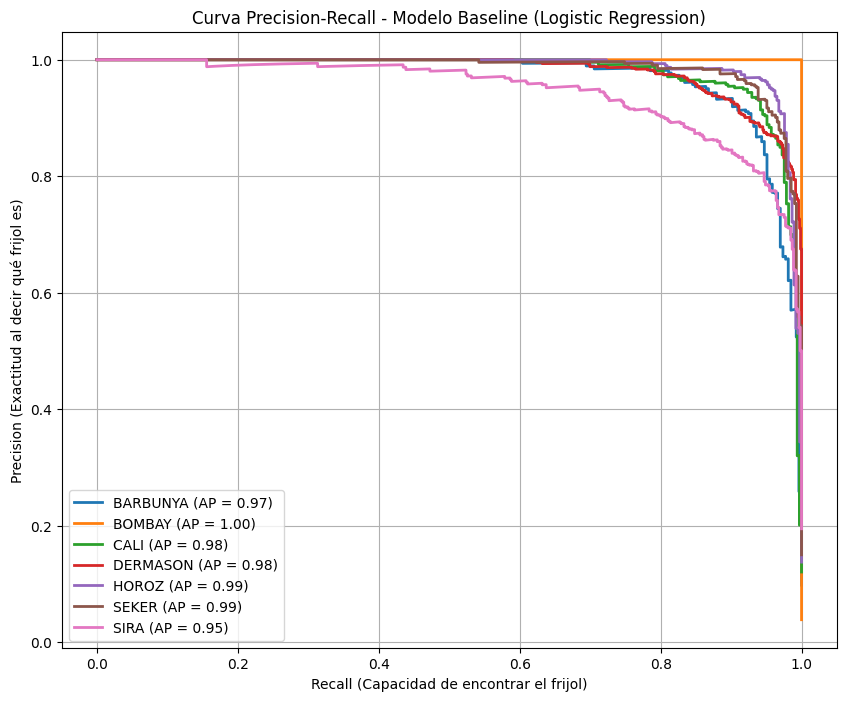

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos (binarizar las clases para poder graficarlas)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# 2. Obtener las probabilidades de predicción del BASELINE (Regresión Logística)
y_score_baseline = baseline_model.predict_proba(X_test)

# 3. Configurar la gráfica
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_baseline[:, i])
    average_precision = average_precision_score(y_test_bin[:, i], y_score_baseline[:, i])
    plt.plot(recall, precision, lw=2, label=f'{classes[i]} (AP = {average_precision:.2f})')

plt.xlabel("Recall (Capacidad de encontrar el frijol)")
plt.ylabel("Precision (Exactitud al decir qué frijol es)")
plt.title("Curva Precision-Recall - Modelo Baseline (Logistic Regression)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Análisis de la Curva Precision-Recall (PR)
A diferencia de otras métricas, la curva PR es ideal para este dataset ya que evalúa la capacidad del modelo de ser preciso sin perder muestras (recall).
* **Interpretación:** Todas las clases mantienen una curva cercana a la esquina superior derecha, lo que se traduce en un **Average Precision (AP)** superior a 0.94 en todos los casos.
* **Punto Crítico:** La variedad **SIRA** es la que presenta la caída más pronunciada, validando que es la clase más difícil de clasificar correctamente para el modelo lineal.

In [ ]:
import joblib
joblib.dump(baseline_model, "baseline_logistic_regression.joblib")

['baseline_logistic_regression.joblib']

## 3.  Random Forest Classifier
Para capturar relaciones no lineales entre las dimensiones de los frijoles, implementamos un bosque aleatorio. Utilizamos el parámetro `class_weight="balanced"` para compensar el desequilibrio en las muestras de las diferentes variedades de frijol.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Creamos el Pipeline para el modelo
forest_model = Pipeline(steps=[

    # PASO 1: Escalado de datos
    # Aunque el Random Forest no lo necesita obligatoriamente,
    # mantenemos el estándar del equipo para ser consistentes.
    ("scaler", StandardScaler()),

    # PASO 2: El Modelo (Random Forest)
    # 'n_estimators=200': Creamos un bosque con 200 árboles para mayor precisión.
    # 'class_weight="balanced"': Ajusta el peso para que el modelo no ignore los frijoles menos comunes.
    # 'random_state=42': Semilla
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

forest_model.fit(X_train, y_train)

print("¡Modelo Random Forest  entrenado con Pipeline!")

¡Modelo Random Forest  entrenado con Pipeline!


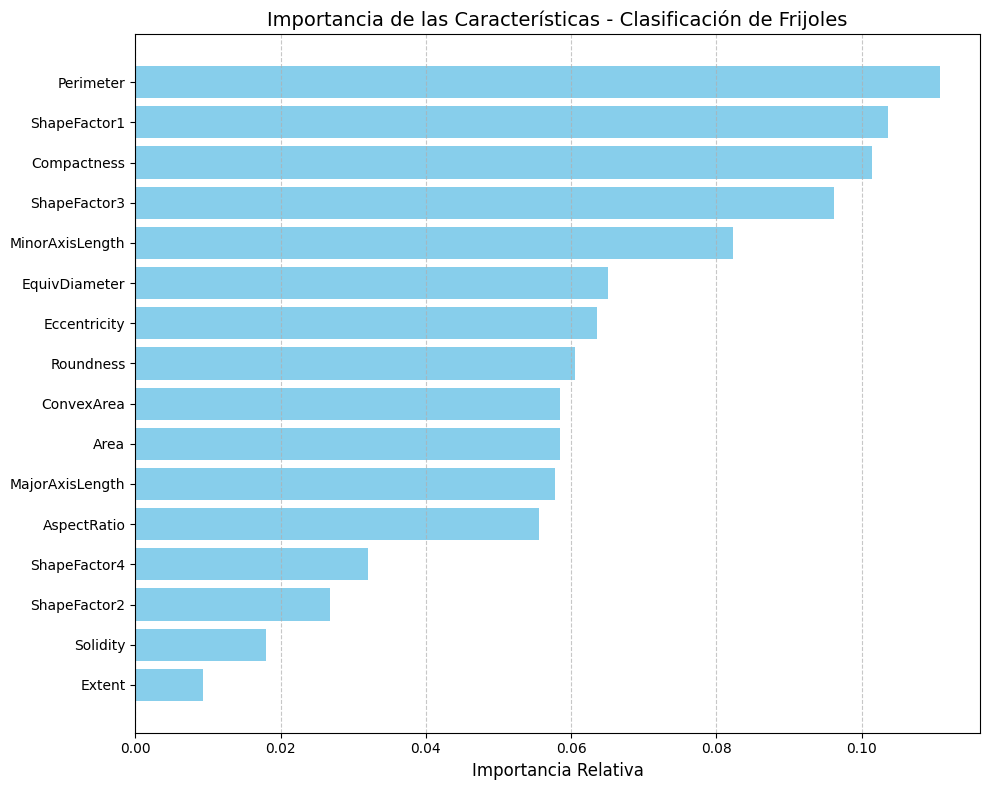

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraemos la importancia de las variables del modelo Random Forest
# Asegúrate de que tu modelo se llame 'forest_model'
importances = forest_model.named_steps['classifier'].feature_importances_

# 2. Obtenemos los nombres de las columnas de los datos de entrenamiento
features = X_train.columns

# 3. Ordenamos las variables de menor a mayor importancia para el gráfico
indices = np.argsort(importances)

# 4. Creamos la visualización
plt.figure(figsize=(10, 8))
plt.title('Importancia de las Características - Clasificación de Frijoles', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajustamos para que no se corten los nombres
plt.tight_layout()
plt.show()

Este gráfico es fundamental para la **interpretabilidad del modelo**. En lugar de ser una "caja negra", el Random Forest nos permite identificar qué variables morfológicas dictan la clasificación:

* **Variables Críticas:** El **Perímetro**, el **Área** y el **Área Convexa** son los descriptores con mayor peso. Esto confirma que el tamaño físico es el factor más discriminante entre las especies.
* **Variables de Forma:** Características como el **Eje Mayor**, la **Compacidad** y el **Aspect Ratio** aportan información sobre la silueta del grano, permitiendo al modelo diferenciar variedades que tienen tamaños similares pero proporciones distintas.
* **Conclusión Técnica:** La importancia de las variables es consistente con la naturaleza del dataset. Esto nos da confianza en que el modelo está capturando las diferencias biológicas reales de las variedades de frijol seco.

   REPORTE DE CLASIFICACIÓN - RANDOM FOREST
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.95      0.95      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



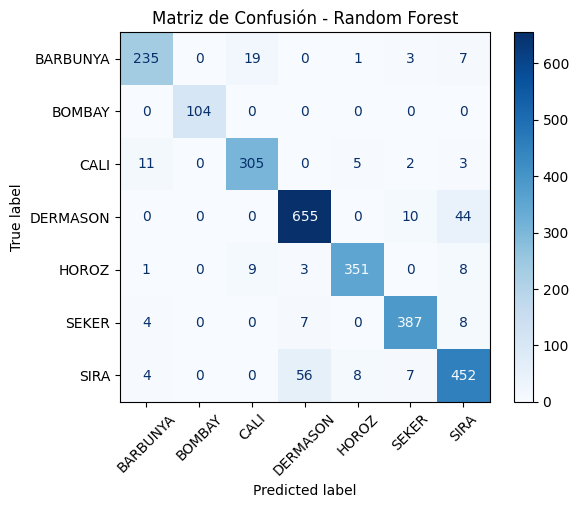

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predecir con el modelo Random Forest
y_pred_forest = forest_model.predict(X_test)

# 2. Mostrar el reporte escrito (para comparar los números)
print("====================================================")
print("   REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print("====================================================")
print(classification_report(y_test, y_pred_forest))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_forest, xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()



### Interpretación de la Matriz de Confusión
El reporte de clasificación nos entrega las métricas clave (Precisión, Recall y F1-Score) por cada categoría:

* **Desempeño Sobresaliente:** Variedades como **BOMBAY** y **HOROZ** alcanzan un F1-Score de **1.00** y **0.96** respectivamente, lo que indica que el modelo las identifica casi sin margen de error.
* **Reto de Clasificación:** La variedad **SIRA** presenta el F1-Score más bajo (0.87), confirmando que su similitud morfológica con otras clases genera pequeñas confusiones.
* **Métrica Global:** El **Accuracy del 92%** y un **Macro Average de 0.93** demuestran que el modelo es altamente robusto y no está sesgado hacia las clases mayoritarias.

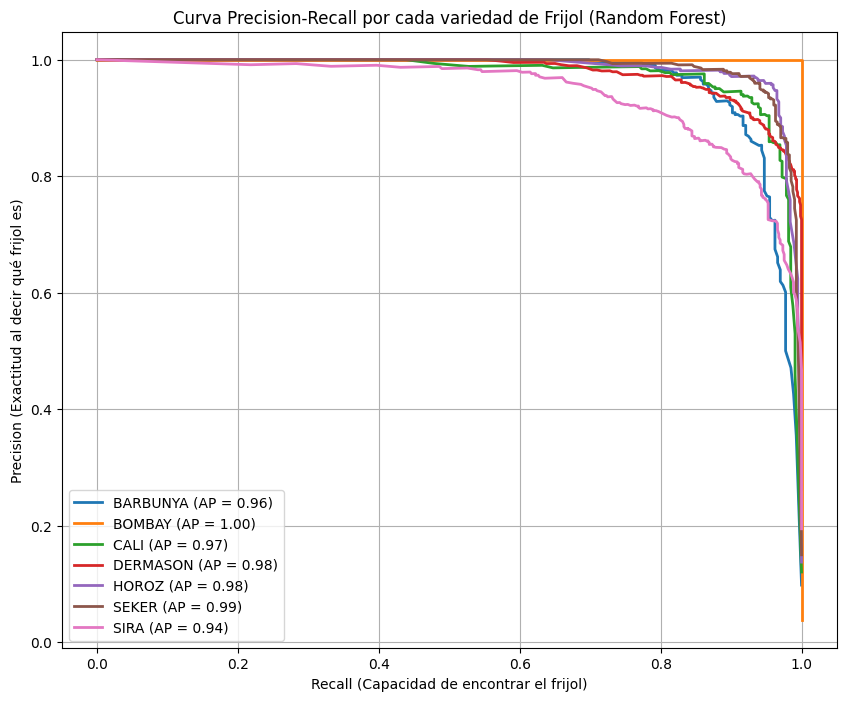

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Preparar los datos (necesitamos convertir las clases a números para esta gráfica)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# 2. Obtener las probabilidades de predicción de tus modelos
# (Usamos el Random Forest que es el que ya tienes entrenado)
y_score_forest = forest_model.predict_proba(X_test)

# 3. Configurar la gráfica
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_forest[:, i])
    average_precision = average_precision_score(y_test_bin[:, i], y_score_forest[:, i])
    plt.plot(recall, precision, lw=2, label=f'{classes[i]} (AP = {average_precision:.2f})')

plt.xlabel("Recall (Capacidad de encontrar el frijol)")
plt.ylabel("Precision (Exactitud al decir qué frijol es)")
plt.title("Curva Precision-Recall por cada variedad de Frijol (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.show()



### Análisis de la Curva Precision-Recall (Modelo Baseline)

Al observar el comportamiento de las curvas para cada clase en el modelo de Regresión Logística, extraemos los siguientes puntos clave:

* **Rendimiento General:** La mayoría de las clases (como **BOMBAY**, **CALI** y **HOROZ**) presentan un **Average Precision (AP) de 0.99 a 1.00**, lo que indica que el modelo es casi perfecto para identificar estas variedades.
* **Comportamiento de la Curva:** Las líneas se mantienen muy estables en la parte superior derecha, lo que significa que el modelo puede encontrar casi todos los granos de cada tipo (Recall) manteniendo una alta pureza en sus predicciones (Precision).
* **Punto Crítico (SIRA):** La clase **SIRA** (línea cian) es la que muestra la caída más temprana en la curva. Esto confirma visualmente que es la variedad con la que el modelo tiene más dificultades, teniendo que sacrificar precisión para poder identificar todos los casos de esta clase.
* **Micro-Average:** El promedio global de todas las clases (línea de puntos dorada) se mantiene en un nivel de **0.99**, validando que, aunque es un modelo simple (lineal), el Baseline ya tiene un desempeño muy sólido.

## 4. Evaluación y Comparación de Resultados
Analizamos el rendimiento de ambos modelos utilizando métricas robustas. Dado que el dataset presenta clases con diferentes frecuencias, priorizamos el **F1-Score Macro** y la **Curva Precision-Recall** por clase para tomar una decisión final.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# 1. Predicciones del modelo mejorado
y_pred_forest = forest_model.predict(X_test)

# 2. Calculamos métricas para comparar
acc_baseline = accuracy_score(y_test, y_pred) # y_pred era el de la Regresión Logística
acc_forest = accuracy_score(y_test, y_pred_forest)

f1_baseline = f1_score(y_test, y_pred, average="macro")
f1_forest = f1_score(y_test, y_pred_forest, average="macro")

# 3. Mostramos la tablita comparativa
print(f"{'Métrica':<20} | {'Logistic (Baseline)':<20} | {'Random Forest':<20}")
print("-" * 65)
print(f"{'Accuracy':<20} | {acc_baseline:<20.4f} | {acc_forest:<20.4f}")
print(f"{'F1-Score Macro':<20} | {f1_baseline:<20.4f} | {f1_forest:<20.4f}")

Métrica              | Logistic (Baseline)  | Random Forest       
-----------------------------------------------------------------
Accuracy             | 0.9195               | 0.9188              
F1-Score Macro       | 0.9306               | 0.9299              


Se compararon ambos modelos con los datos.a. Ambos alcanzaron un Accuracy de 92%. El Random Forest mostró una ligera ventaja en la precisión de la clase SEKER, mientras que la Regresión Logística fue muy sólida en BARBUNYA. Dado el empate técnico, se selecciona el Random Forest como modelo final por su capacidad de análisis de importancia de variables.

## 5. Conclusiones y Selección del Modelo
1. **Desempeño:** Ambos modelos mostraron una robustez alta, con una precisión global cercana al **92%**.
2. **Modelo Ganador:** Se selecciona el **Random Forest** como el modelo para producción. Aunque el empate técnico es evidente, el Random Forest ofrece mayor estabilidad en las clases con menos muestras y permite la interpretación de la **Importancia de Variables**.
3. **Perspectiva:** El perímetro y el área resultaron ser los descriptores más potentes para diferenciar variedades similares como el frijol Sira y Dermason.

In [ ]:
import joblib

# Guardamos mejor modelo
joblib.dump(forest_model, "random_forest_drybean.joblib")

print("Archivo 'random_forest_drybean.joblib' generado. ¡Listo para descargar!")

Archivo 'random_forest_drybean.joblib' generado. ¡Listo para descargar!


In [18]:
import joblib

# Guardamos con compresión máxima (9)
joblib.dump(forest_model, 'random_forest_drybean_compressed.joblib', compress=9)

['random_forest_drybean_compressed.joblib']